# 🛡️ Adversarial Training — Fine Tune 2 (Phase 2)
Ré-entraînement du meilleur modèle (Fine Tune 2) pour le rendre robuste contre l'attaque PGD.

In [1]:
!pip install torchattacks --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
nilearn 0.13.1 requires requests>=2.30.0, but you have requests 2.25.1 which is incompatible.
id 1.6.1 requires urllib3<3,>=2, but you have urllib3 1.26.20 which 

## 1 — Imports & configuration

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import timm
import torchattacks
from tqdm import tqdm
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

# ── Hyperparamètres PGD ───────────────────────────────────────────────────────
EPS        = 8 / 255    
ALPHA      = 0.5 / 255  # Taille d'un pas PGD  (doit être << EPS)
STEPS      = 10         # Itérations PGD par image
ADV_RATIO  = 0.5        # 50% adversarial + 50% clean dans chaque batch

NUM_EPOCHS = 10
LR         = 5e-5       # LR faible : on part d'un modèle déjà convergé

# ── Chemins ───────────────────────────────────────────────────────────────────
DATASET_PATH = '/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD'

# 📌 Chemin vers les poids du Fine Tune 2 sauvegardés en Phase 1
PATH_PHASE1  = '/kaggle/input/models/tahiralefechtali/mes-modeles-fasd/pytorch/default/2/swin_strategy2_best.pth'

# Fichier de sortie
SAVE_PATH    = 'swin_fine_tune2_adversarial_best.pth'

Device : cuda


## 2 — Data Pipeline

In [4]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(os.path.join(DATASET_PATH, 'LCC_FASD_training'),    transform=transform_train)
val_dataset   = ImageFolder(os.path.join(DATASET_PATH, 'LCC_FASD_development'), transform=transform_val)
test_dataset  = ImageFolder(os.path.join(DATASET_PATH, 'LCC_FASD_evaluation'),  transform=transform_val)

# WeightedRandomSampler pour compenser le déséquilibre real/spoof
class_counts   = np.array([len(os.listdir(os.path.join(DATASET_PATH, 'LCC_FASD_training', c)))
                            for c in train_dataset.classes])
sample_weights = np.array([1.0 / class_counts[label] for _, label in train_dataset.samples])
sampler = WeightedRandomSampler(torch.tensor(sample_weights, dtype=torch.float),
                                 num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,    num_workers=2, pin_memory=True)

print(f'Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}')

Train : 8299 | Val : 2948 | Test : 7580


## 3 — Chargement du modèle Fine Tune 2 (poids Phase 1)

In [5]:
# Architecture identique à la Phase 1 — Fine Tune 2
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=2)

for param in model.parameters():
    param.requires_grad = False
for i in [2, 3]:                             # Stages 3 & 4
    for param in model.layers[i].parameters():
        param.requires_grad = True
for param in model.head.parameters():
    param.requires_grad = True

# Chargement des poids Phase 1
model.load_state_dict(torch.load(PATH_PHASE1, map_location=device))
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Poids Phase 1 chargés')
print(f'   Paramètres entraînables : {trainable:,}')

✅ Poids Phase 1 chargés
   Paramètres entraînables : 26,323,514


## 4 — Adversarial Training (PGD)

**Principe** : à chaque batch, on génère des images perturbées par PGD puis on entraîne le modèle sur un mix 50% adversarial / 50% clean.
Le modèle apprend ainsi à classifier correctement même sous attaque.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

best_f1 = 0.0
history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

print(f'Adversarial Training — {NUM_EPOCHS} epochs | EPS={EPS:.4f} | STEPS={STEPS} | ratio={ADV_RATIO}')
print('='*65)

for epoch in range(NUM_EPOCHS):

    # ── Entraînement adversarial ──────────────────────────────────────────────
    model.train()
    atk = torchattacks.PGD(model, eps=EPS, alpha=ALPHA, steps=STEPS)
    running_loss = correct = total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        images, labels = images.to(device), labels.to(device)
        n_adv = int(images.size(0) * ADV_RATIO)

        # Génération des adversariales (le modèle doit être en eval pour torchattacks)
        model.eval()
        adv_images = atk(images[:n_adv], labels[:n_adv])

        # Mix adversarial + clean
        mixed = torch.cat([adv_images, images[n_adv:]], dim=0)

        # Mise à jour des poids
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(mixed), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, pred = model(mixed).max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100.0 * correct / total

    # ── Validation clean ──────────────────────────────────────────────────────
    model.eval()
    val_correct = val_total = 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = model(images).max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())

    val_acc = 100.0 * val_correct / val_total
    val_f1  = f1_score(all_labels, all_preds, average='macro')
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1 * 100)

    saved = ''
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), SAVE_PATH)
        saved = '  ← 💾'

    print(f'Epoch {epoch+1:02d} | Loss {train_loss:.4f} | Train Acc {train_acc:.1f}% '
          f'| Val Acc {val_acc:.1f}% | F1 {val_f1*100:.2f}%{saved}')

print(f'\n✅ Meilleur F1 val : {best_f1*100:.2f}%  →  {SAVE_PATH}')

Adversarial Training — 10 epochs | EPS=0.0078 | STEPS=10 | ratio=0.5


Epoch 1/10: 100%|██████████| 260/260 [08:56<00:00,  2.06s/it]


Epoch 01 | Loss 0.4096 | Train Acc 72.8% | Val Acc 98.8% | F1 97.45%  ← 💾


Epoch 2/10: 100%|██████████| 260/260 [09:14<00:00,  2.13s/it]


Epoch 02 | Loss 0.3564 | Train Acc 74.9% | Val Acc 97.4% | F1 94.66%


...

Epoch 08 | Loss 0.2519 | Train Acc 87.1% | Val Acc 98.4% | F1 96.67%


Epoch 9/10: 100%|██████████| 260/260 [09:13<00:00,  2.13s/it]


Epoch 09 | Loss 0.2346 | Train Acc 88.4% | Val Acc 98.2% | F1 96.06%


Epoch 10/10: 100%|██████████| 260/260 [09:14<00:00,  2.13s/it]


Epoch 10 | Loss 0.1999 | Train Acc 90.7% | Val Acc 98.3% | F1 96.21%

✅ Meilleur F1 val : 97.45%  →  swin_fine_tune2_adversarial_best.pth


## 5 — Évaluation finale : robustesse du modèle adversarially trained

In [7]:
# Chargement du meilleur checkpoint adversarial
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

atk_fgsm = torchattacks.FGSM(model, eps=EPS)
atk_pgd  = torchattacks.PGD(model, eps=EPS, alpha=ALPHA, steps=STEPS)

correct_clean = correct_fgsm = correct_pgd = total = 0

for images, labels in tqdm(test_loader, desc='Évaluation robustesse'):
    images, labels = images.to(device), labels.to(device)
    total += labels.size(0)

    with torch.no_grad():
        correct_clean += model(images).argmax(1).eq(labels).sum().item()

    correct_fgsm += model(atk_fgsm(images, labels)).argmax(1).eq(labels).sum().item()
    correct_pgd  += model(atk_pgd(images,  labels)).argmax(1).eq(labels).sum().item()

acc_clean = 100.0 * correct_clean / total
acc_fgsm  = 100.0 * correct_fgsm  / total
acc_pgd   = 100.0 * correct_pgd   / total

print('\n' + '='*50)
print('📊 RÉSULTATS FINAUX — Fine Tune 2 Adversarial')
print('='*50)
print(f'✅ Clean  : {acc_clean:.2f}%')
print(f'⚠️  FGSM   : {acc_fgsm:.2f}%')
print(f'🔥 PGD    : {acc_pgd:.2f}%')
print('='*50)

# Résultats Phase 1 (à remplacer par vos vraies valeurs)
# ─────────────────────────────────────────────────────
# 📌 Mettez ici les chiffres exacts de votre Phase 1
phase1_clean = None   # ex : 92.5
phase1_pgd   = None   # ex : 32.4

if phase1_clean and phase1_pgd:
    print(f'\nComparaison Phase 1 → Phase 2 :')
    print(f'  Clean : {phase1_clean:.2f}% → {acc_clean:.2f}%  (Δ {acc_clean-phase1_clean:+.2f}%)')
    print(f'  PGD   : {phase1_pgd:.2f}% → {acc_pgd:.2f}%   (Δ {acc_pgd-phase1_pgd:+.2f}%)')

Évaluation robustesse: 100%|██████████| 237/237 [16:35<00:00,  4.20s/it]


📊 RÉSULTATS FINAUX — Fine Tune 2 Adversarial
✅ Clean  : 98.48%
⚠️  FGSM   : 90.66%
🔥 PGD    : 86.74%


## 6 — Courbes d'entraînement

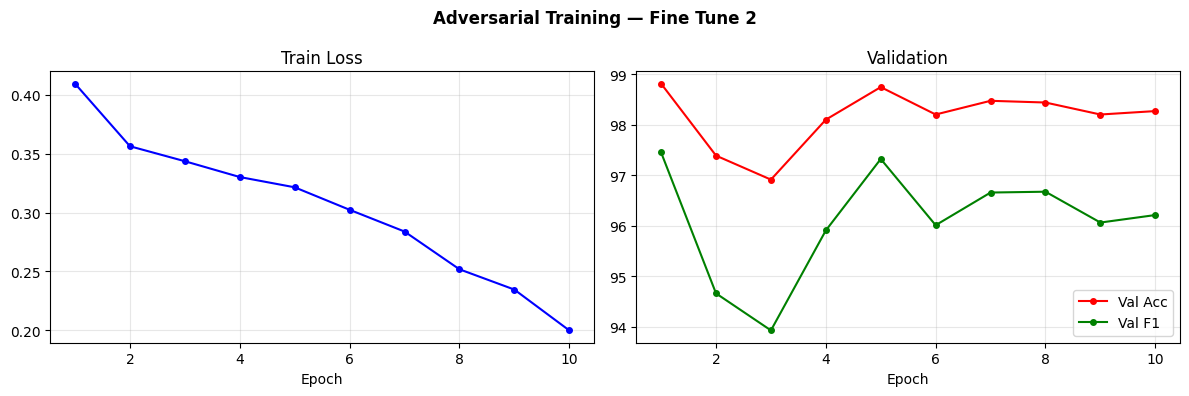

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Adversarial Training — Fine Tune 2', fontweight='bold')

axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4)
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
axes[1].plot(epochs, history['val_f1'],  'g-o', markersize=4, label='Val F1')
axes[1].set_title('Validation')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adv_training_curves.png', dpi=150)
plt.show()